# SSH-Bruteforce - GMM

## Import libraries

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## GMM training

In [ ]:
filenames = [5]

labels_str = ['DDoS', 'Benign', 'DoS', 'Bot', 'BruteForce', 'SSH-Bruteforce', 'Web']

filenames

pd.set_option('future.no_silent_downcasting', True)

[1]

BIC score applied to decide the number of GMM components (1 -10)

1


Label
0    514148
2    369871
3    329224
4    243806
5    183163
6       596
Name: count, dtype: int64

Tipo: 0 = Benign
Melhor modelo: n_componentes: 10 covariance_type: full


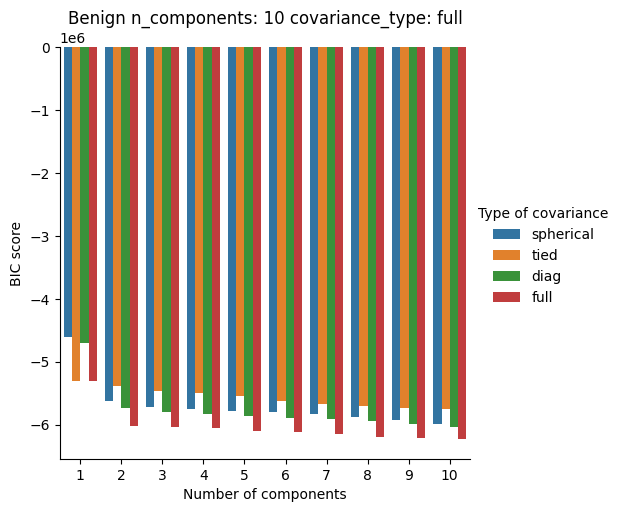

Tipo: 2 = DDoS
Melhor modelo: n_componentes: 10 covariance_type: full


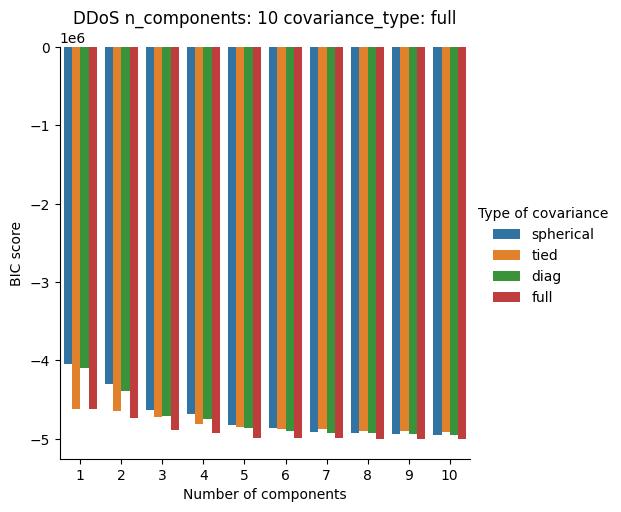

Tipo: 3 = DoS
Melhor modelo: n_componentes: 9 covariance_type: full


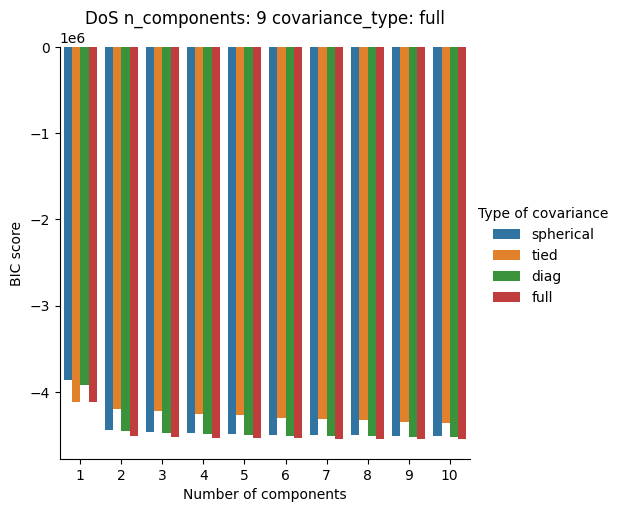

Tipo: 4 = BruteForce
Melhor modelo: n_componentes: 4 covariance_type: full


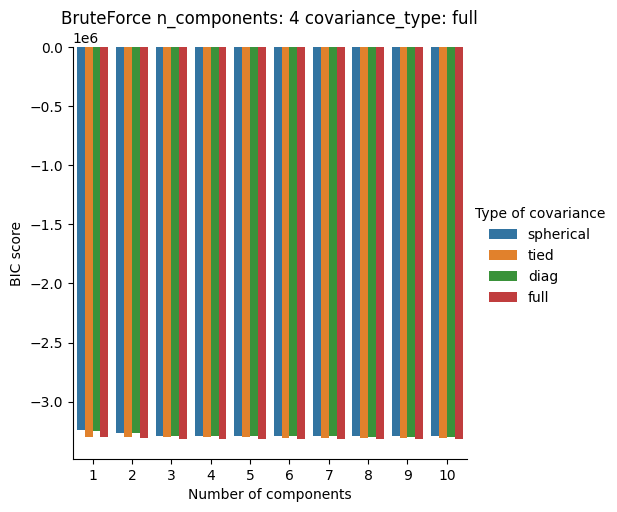

Tipo: 5 = Bot
Melhor modelo: n_componentes: 10 covariance_type: full


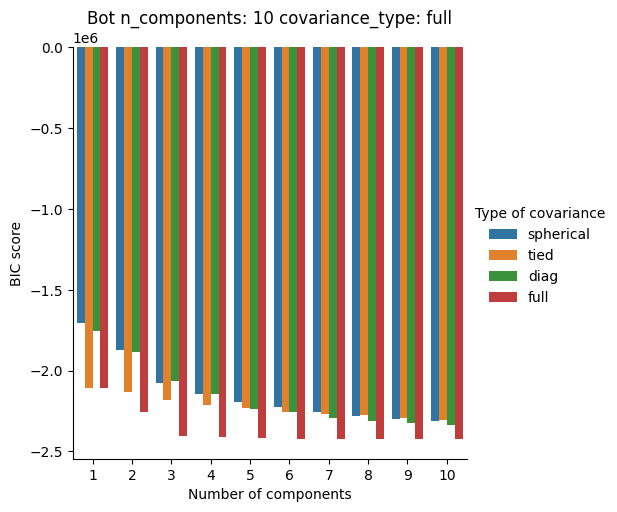

Tipo: 6 = Web
Melhor modelo: n_componentes: 4 covariance_type: full


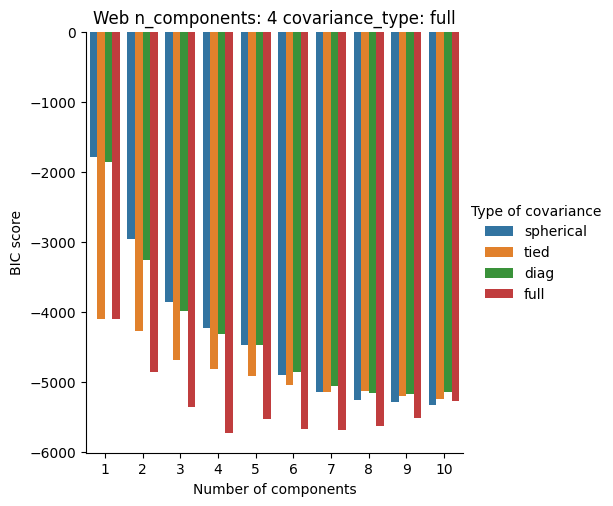

,0,1,2,3,4,5,6
0,13.207030,NaN,-46.087940,-44.021201,-1684.679225,7.109177,16.633128
1,22.308842,NaN,34.035015,-99.156201,-1418.143036,13.675738,18.347957
2,31.491988,NaN,0.751433,3.799856,-1082.088990,18.366965,19.689166
3,25.350849,NaN,4.335551,1.016555,-1145.346434,15.139191,19.361279
4,18.435080,NaN,-6.435152,-0.386550,-666.667127,6.572854,18.135551
...,...,...,...,...,...,...,...
649942,32.494362,NaN,5.482691,3.958238,-1073.242275,17.942886,19.320032
649943,18.227365,NaN,-8.607884,-0.301188,-648.472091,6.818072,18.280635
649944,18.074392,NaN,-9.114130,-0.894366,-652.885206,5.759533,18.116263
649945,9.049613,NaN,-1094.398977,-25.470023,34.247041,-72.018726,8.857130


In [ ]:
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import GridSearchCV
import seaborn as sns
import os

def gmm_bic_score(estimator, X):
    """Callable to pass to GridSearchCV that will use the BIC score."""
    # Make it negative since GridSearchCV expects a score to maximize
    return -estimator.bic(X)


param_grid = {
    "n_components": range(1, 11),
    "covariance_type": ["spherical", "tied", "diag", "full"],
    "random_state": [123],
}

exp_train = []
exp_test = []
y_true_all_exp_train = []
y_true_all_exp_test = []
for z in range(len(filenames)):
    
    train_encoded_df = pd.read_csv(f'train_encoded_{filenames[z]}_hidden.csv')
    test_encoded_df = pd.read_csv(f'test_encoded_{filenames[z]}_hidden.csv')
    y_true_all_exp_train.append(train_encoded_df['Label'].values.tolist())
    y_true_all_exp_test.append(test_encoded_df['Label'].values.tolist())
    print(filenames[z])
    hidden_classes = [filenames[z]] # Classes hidden from training
    for i in range(len(labels_str)):
        train_encoded_df['Label'] = train_encoded_df['Label'].replace(labels_str[i],i)
        test_encoded_df['Label'] = test_encoded_df['Label'].replace(labels_str[i],i)

    display(train_encoded_df['Label'].value_counts())
        
    
        
    gmms = []
    for i in range(len(labels_str)):
        if i not in hidden_classes:
            print(f'Type: {i} = {labels_str[i]}')
            grid_search = GridSearchCV(
                GaussianMixture(), param_grid=param_grid, scoring=gmm_bic_score
            )
            grid_search.fit(train_encoded_df[train_encoded_df['Label'] == i].drop(columns=['Label']).to_numpy())
            print(f"Best model: n_componentes: {grid_search.best_params_['n_components']} covariance_type: {grid_search.best_params_['covariance_type']}")
            gmms.append(grid_search.best_estimator_)
            df = pd.DataFrame(grid_search.cv_results_)[
                ["param_n_components", "param_covariance_type", "mean_test_score"]
            ]
            df["mean_test_score"] = -df["mean_test_score"]
            df = df.rename(
                columns={
                    "param_n_components": "Number of components",
                    "param_covariance_type": "Type of covariance",
                    "mean_test_score": "BIC score",
                }
            )
            df.sort_values(by="BIC score").head()
            sns.catplot(
                data=df,
                kind="bar",
                x="Number of components",
                y="BIC score",
                hue="Type of covariance",
                
            ).set(title = f"{labels_str[i]} n_components: {grid_search.best_params_['n_components']} covariance_type: {grid_search.best_params_['covariance_type']}")
            plt.show()
        else:
            gmms.append(None)
    
    
    scores = []
    for i, row in test_encoded_df.drop(columns=['Label']).iterrows():
        max_dist = -np.inf
        pred = -1
        scores.append([])
        for j in range(len(labels_str)):
            if j not in hidden_classes:
                inside = False
                max = -np.inf
                score = gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0]
                scores[i].append(score)
            else:
                scores[i].append(np.nan)
    
    
    display(pd.DataFrame(scores))
    exp_test.append(scores)
    scores_df = pd.DataFrame(scores)
    scores_df['Label'] = test_encoded_df["Label"].values
    scores_df.to_csv(f'test_{filenames[z]}_GMM_BIC_1_10_scores.csv', index=False)